KNN Gen 1: Best K=9, Accuracy=0.9649
KNN Gen 2: Best K=9, Accuracy=0.9649
KNN Gen 3: Best K=9, Accuracy=0.9649
KNN Gen 4: Best K=9, Accuracy=0.9649
KNN Gen 5: Best K=9, Accuracy=0.9649
KNN Gen 6: Best K=9, Accuracy=0.9649
KNN Gen 7: Best K=9, Accuracy=0.9649
KNN Gen 8: Best K=9, Accuracy=0.9649
KNN Gen 9: Best K=9, Accuracy=0.9649
KNN Gen 10: Best K=9, Accuracy=0.9649
KNN Gen 11: Best K=9, Accuracy=0.9649
KNN Gen 12: Best K=9, Accuracy=0.9649
KNN Gen 13: Best K=9, Accuracy=0.9649
KNN Gen 14: Best K=9, Accuracy=0.9649
KNN Gen 15: Best K=9, Accuracy=0.9649
KNN Gen 16: Best K=9, Accuracy=0.9649
KNN Gen 17: Best K=9, Accuracy=0.9649
KNN Gen 18: Best K=9, Accuracy=0.9649
KNN Gen 19: Best K=9, Accuracy=0.9649
KNN Gen 20: Best K=9, Accuracy=0.9649
KNN Gen 21: Best K=9, Accuracy=0.9649
KNN Gen 22: Best K=9, Accuracy=0.9649
KNN Gen 23: Best K=9, Accuracy=0.9649
KNN Gen 24: Best K=9, Accuracy=0.9649
KNN Gen 25: Best K=9, Accuracy=0.9649
KNN Gen 26: Best K=9, Accuracy=0.9649
KNN Gen 27: Best K=9,

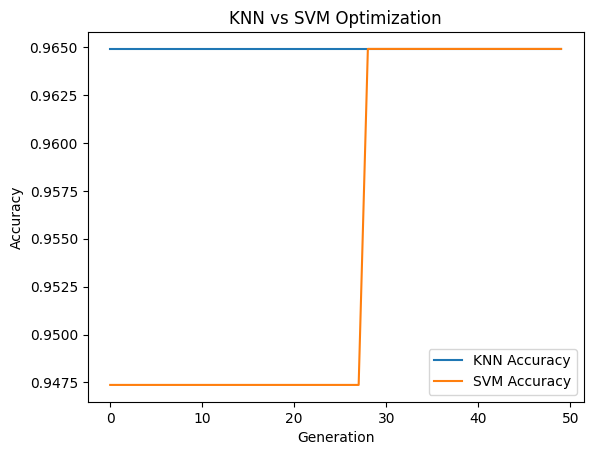

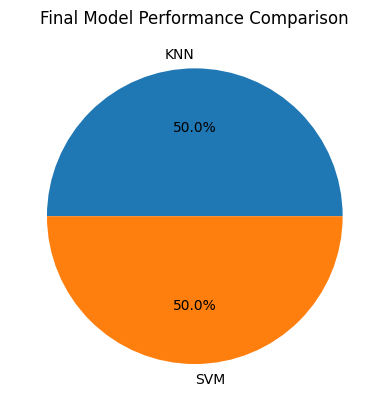

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# -----------------------------
# LOAD DATA
# -----------------------------
data = pd.read_csv('/content/data.csv')

# Drop columns that are entirely empty (like 'Unnamed: 32' which often appears in this dataset)
data = data.dropna(axis=1, how='all')

# Select target column
# If 'diagnosis' is in columns, use it; otherwise use the last column
target_col = 'diagnosis' if 'diagnosis' in data.columns else data.columns[-1]

# Remove rows with missing target
data = data.dropna(subset=[target_col])

# Split features and target
X = data.drop(columns=[target_col])
y = data[target_col]

# Drop 'id' if it exists as it's not a useful feature
if 'id' in X.columns:
    X = X.drop(columns=['id'])

# Convert text labels to numbers for target
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Convert any remaining categorical columns in X to numerical using one-hot encoding
X = pd.get_dummies(X)

# Fill remaining missing values in X with column means (after get_dummies)
X = X.fillna(X.mean(numeric_only=True))

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# GA PARAMETERS
# -----------------------------
POP_SIZE = 10
GENERATIONS = 50
MUTATION_RATE = 0.1

# =====================================================
# 🔵 GA FOR KNN (Optimize K)
# =====================================================
def fitness_knn(k):
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

# Initialize population
knn_population = [random.randint(1, 20) for _ in range(POP_SIZE)]

knn_best_scores = []

for gen in range(GENERATIONS):
    scores = [(k, fitness_knn(k)) for k in knn_population]
    scores.sort(key=lambda x: x[1], reverse=True)

    best_k, best_score = scores[0]
    knn_best_scores.append(best_score)

    print(f"KNN Gen {gen+1}: Best K={best_k}, Accuracy={best_score:.4f}")

    selected = [k for k, _ in scores[:POP_SIZE // 2]]

    new_pop = selected.copy()

    while len(new_pop) < POP_SIZE:
        parent1 = random.choice(selected)
        parent2 = random.choice(selected)

        child = int((parent1 + parent2) / 2)

        if random.random() < MUTATION_RATE:
            child = random.randint(1, 20)

        new_pop.append(child)

    knn_population = new_pop

best_k = max(knn_population, key=fitness_knn)
best_knn_acc = fitness_knn(best_k)

# =====================================================
# 🔴 GA FOR SVM (Optimize C & Gamma)
# =====================================================
def fitness_svm(ind):
    C, gamma = ind
    model = SVC(C=C, gamma=gamma)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

# Initialize population
svm_population = [(random.uniform(0.1, 100), random.uniform(0.001, 1))
                  for _ in range(POP_SIZE)]

svm_best_scores = []

for gen in range(GENERATIONS):
    scores = [(ind, fitness_svm(ind)) for ind in svm_population]
    scores.sort(key=lambda x: x[1], reverse=True)

    best_ind, best_score = scores[0]
    svm_best_scores.append(best_score)

    print(f"SVM Gen {gen+1}: C={best_ind[0]:.2f}, Gamma={best_ind[1]:.4f}, Acc={best_score:.4f}")

    selected = [ind for ind, _ in scores[:POP_SIZE // 2]]

    new_pop = selected.copy()

    while len(new_pop) < POP_SIZE:
        p1 = random.choice(selected)
        p2 = random.choice(selected)

        child = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)

        if random.random() < MUTATION_RATE:
            child = (random.uniform(0.1, 100), random.uniform(0.001, 1))

        new_pop.append(child)

    svm_population = new_pop

best_svm = max(svm_population, key=fitness_svm)
best_svm_acc = fitness_svm(best_svm)

# =====================================================
# 📊 FINAL RESULTS
# =====================================================
print("\n--- FINAL RESULTS ---")
print(f"KNN → Best K = {best_k}, Accuracy = {best_knn_acc:.4f}")
print(f"SVM → Best C = {best_svm[0]:.2f}, Gamma = {best_svm[1]:.4f}, Accuracy = {best_svm_acc:.4f}")

# =====================================================
# 📈 GRAPH: KNN vs SVM
# =====================================================
plt.figure()
plt.plot(knn_best_scores, label="KNN Accuracy")
plt.plot(svm_best_scores, label="SVM Accuracy")
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("KNN vs SVM Optimization")
plt.legend()
plt.show()

# =====================================================
# 📊 PIE CHART: FINAL COMPARISON
# =====================================================
labels = ['KNN', 'SVM']
sizes = [best_knn_acc, best_svm_acc]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Final Model Performance Comparison")
plt.show()